*Member's name:
- Damiya Aina binti Basir Abd Shammad (A23CS0220)
- Ain Nurnabila binti Mohd Azhar (A23CS0207)
- Nurul Asyikin binti Khairul Anuar (A23CS0162)

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

# 1. load data
import pandas as pd
rainfall_df = pd.read_csv("Rainfall.csv")
rainfall_df = rainfall_df.iloc[:, 0].str.split(",", expand=True)
rainfall_df.columns = [
    "Region", "Year", "Month", "Station", "Rainfall_mm",
    "RainyDays", "MaxTemp_C", "MinTemp_C", "UrbanRural"
]
rainfall_df["Rainfall_mm"] = pd.to_numeric(rainfall_df["Rainfall_mm"])
rainfall_df["RainyDays"] = pd.to_numeric(rainfall_df["RainyDays"])
rainfall_df["MaxTemp_C"] = pd.to_numeric(rainfall_df["MaxTemp_C"])
rainfall_df["MinTemp_C"] = pd.to_numeric(rainfall_df["MinTemp_C"])

# 2. display
print("First 5 rows of the dataset:")
print(rainfall_df.head())

# 3. missing values
print("\nMissing values in each column:")
print(rainfall_df.isnull().sum())

# summary
summary_stats = rainfall_df.describe().loc[["mean", "50%", "min", "max"]]
summary_stats.rename(index={"50%": "median"}, inplace=True)
print("\nSummary statistics for numerical columns:")
print(summary_stats)

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [2]:
station_stats = rainfall_df.groupby("Station").agg({
    "Rainfall_mm": "sum",
    "RainyDays": "mean",
    "MaxTemp_C": "mean",
    "MinTemp_C": "mean"
})

station_stats.columns = [
    "Total_Rainfall_mm",
    "Avg_RainyDays",
    "Avg_MaxTemp_C",
    "Avg_MinTemp_C"
]

print("Station-wise statistics:")
print(station_stats)

Station-wise statistics:
          Total_Rainfall_mm  Avg_RainyDays  Avg_MaxTemp_C  Avg_MinTemp_C
Station                                                                 
StationA              128.3           10.5          13.40           2.75
StationB              122.0           10.5          13.10           2.50
StationC              144.4           12.0          19.85           7.45
StationD              105.3            9.0          16.65           5.90
StationE              161.6           12.5          17.50           5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [3]:
region_urban_stats = rainfall_df.groupby(["Region", "UrbanRural"]).agg({
    "Rainfall_mm": "mean",
    "MaxTemp_C": "mean",
    "RainyDays": "mean"
})

region_urban_stats.columns = [
    "Avg_Rainfall_mm",
    "Avg_MaxTemp_C",
    "Avg_RainyDays"
]

print("Average statistics by Region and Urban/Rural:")
print(region_urban_stats)

Average statistics by Region and Urban/Rural:
                   Avg_Rainfall_mm  Avg_MaxTemp_C  Avg_RainyDays
Region UrbanRural                                               
East   Rural                 52.65          16.65            9.0
North  Rural                 61.00          13.10           10.5
       Urban                 64.15          13.40           10.5
South  Urban                 72.20          19.85           12.0
West   Urban                 80.80          17.50           12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [4]:
month_region_stats = rainfall_df.groupby(["Month", "Region"]).agg({
    "Rainfall_mm": ["sum", "mean", "min", "max"]
})

month_region_stats.columns = [
    "Total_Rainfall_mm",
    "Mean_Rainfall_mm",
    "Min_Rainfall_mm",
    "Max_Rainfall_mm"
]

print("Rainfall statistics by Month and Region:")
print(month_region_stats)

Rainfall statistics by Month and Region:
              Total_Rainfall_mm  Mean_Rainfall_mm  Min_Rainfall_mm  \
Month Region                                                         
Feb   East                 59.6             59.60             59.6   
      North                72.1             72.10             72.1   
      South                63.4             63.40             63.4   
      West                 84.2             84.20             84.2   
Jan   East                 45.7             45.70             45.7   
      North               116.7             58.35             56.2   
      South                81.0             81.00             81.0   
      West                 77.4             77.40             77.4   
Mar   North                61.5             61.50             61.5   

              Max_Rainfall_mm  
Month Region                   
Feb   East               59.6  
      North              72.1  
      South              63.4  
      West               84.

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [5]:
max_rainfall_row = rainfall_df.loc[rainfall_df["Rainfall_mm"].idxmax()]
region = max_rainfall_row["Region"]
month = max_rainfall_row["Month"]
rainfall = max_rainfall_row["Rainfall_mm"]
print(f"The highest recorded rainfall is {rainfall} mm in {region} during {month}.")

The highest recorded rainfall is 84.2 mm in West during Feb.


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [6]:
year_urban_stats = rainfall_df.groupby(["Year", "UrbanRural"]).agg({
    "Rainfall_mm": ["mean", "min", "max"]
})
year_urban_stats.columns = [
    "Avg_Rainfall_mm",
    "Min_Rainfall_mm",
    "Max_Rainfall_mm"
]
print("Rainfall statistics by Year and Urban/Rural group:")
print(year_urban_stats)

Rainfall statistics by Year and Urban/Rural group:
                 Avg_Rainfall_mm  Min_Rainfall_mm  Max_Rainfall_mm
Year UrbanRural                                                   
2023 Rural             56.825000             45.7             61.5
     Urban             72.383333             56.2             84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [7]:
rainfall_df["Temp_Range"] = rainfall_df["MaxTemp_C"] - rainfall_df["MinTemp_C"]
region_temp_range = rainfall_df.groupby(["Region", "Month"])["Temp_Range"].mean()
print("Average monthly temperature range by Region:")
print(region_temp_range)

Average monthly temperature range by Region:
Region  Month
East    Feb      11.7
        Jan       9.8
North   Feb      11.7
        Jan       9.5
        Mar      11.8
South   Feb      12.4
        Jan      12.4
West    Feb      12.9
        Jan      11.9
Name: Temp_Range, dtype: float64


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



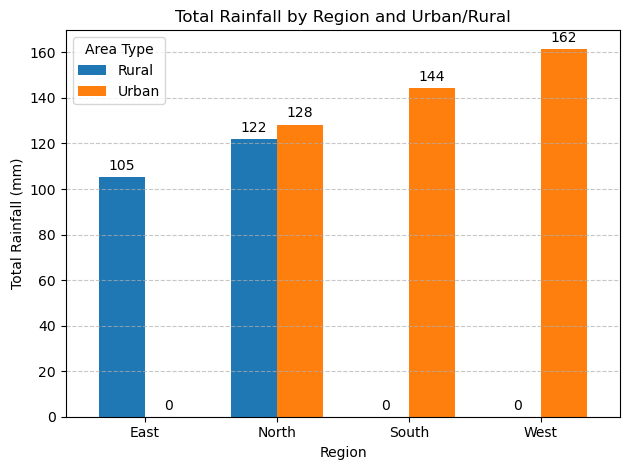

In [9]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure folder exists for saving plots
os.makedirs("figures", exist_ok=True)

# Group total rainfall by Region and UrbanRural
bar_data = rainfall_df.groupby(["Region", "UrbanRural"])["Rainfall_mm"].sum().unstack()

# Plotting the bar chart
ax = bar_data.plot(kind="bar", width=0.7)

plt.title("Total Rainfall by Region and Urban/Rural")
plt.xlabel("Region")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type='edge', padding=3)

plt.legend(title="Area Type")
plt.xticks(rotation=0)
plt.tight_layout()

# Save figure to the new folder
plt.savefig("figures/bar_total_rainfall_region_urbanrural.png")
plt.show()


2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



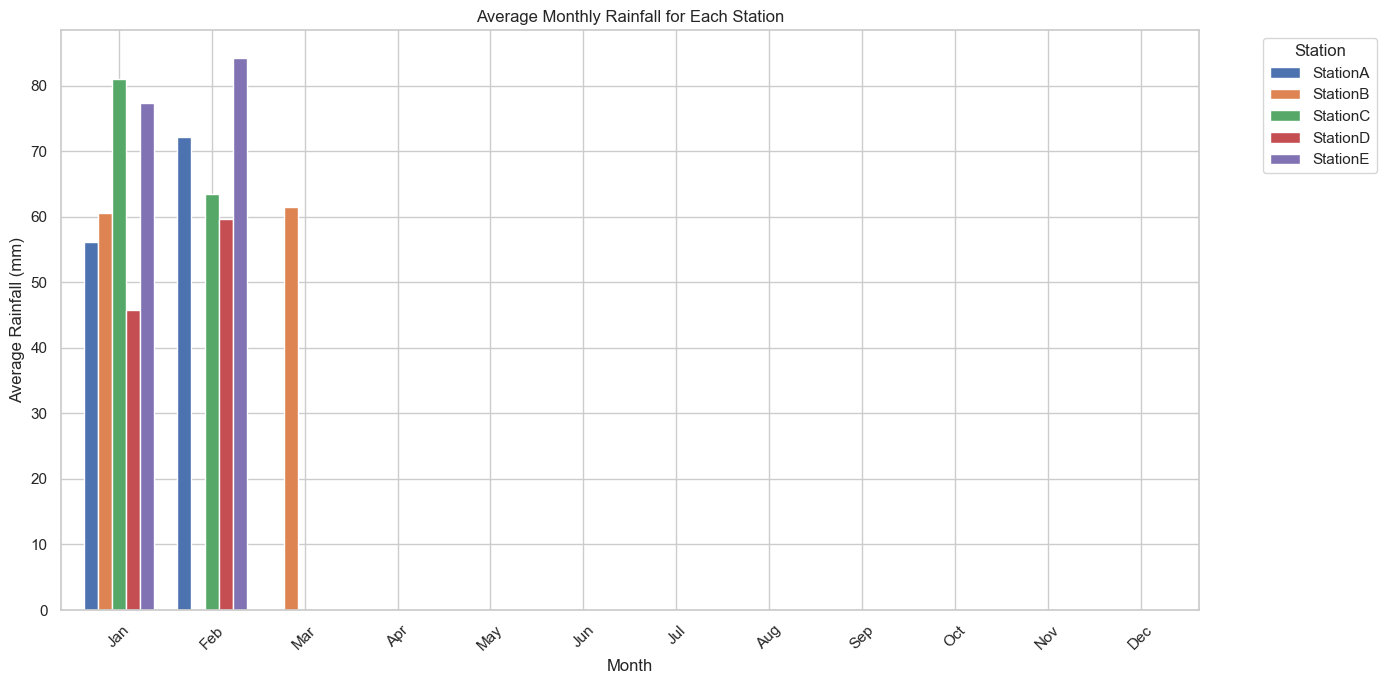

In [10]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'figures' folder exists
os.makedirs("figures", exist_ok=True)

# Set seaborn style for nice colors
sns.set(style="whitegrid")

# Group data: average monthly rainfall for each station
station_month_avg = rainfall_df.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

# Ensure month order is correct
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
station_month_avg = station_month_avg.reindex(month_order)

# Plot the grouped bar chart
ax = station_month_avg.plot(kind="bar", figsize=(14, 7), width=0.75)

# Titles and labels
plt.title("Average Monthly Rainfall for Each Station")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")

# Customize ticks and legend
plt.xticks(rotation=45)
plt.legend(title="Station", bbox_to_anchor=(1.05, 1), loc='upper left')

# Layout and save
plt.tight_layout()
plt.savefig("figures/grouped_avg_monthly_rainfall_station.png")
plt.show()



3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



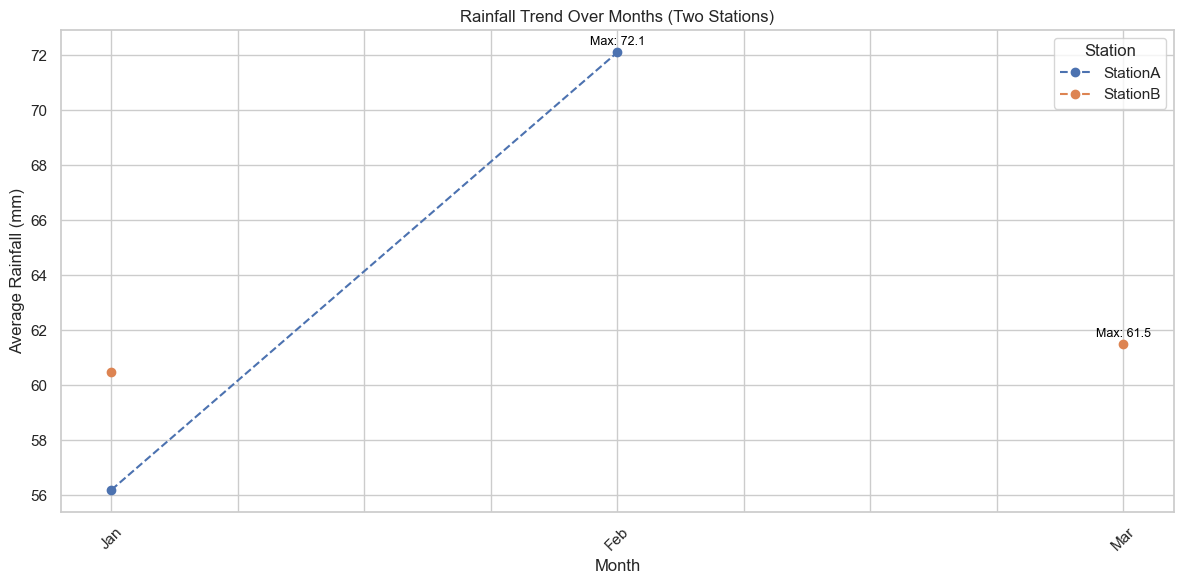

In [11]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'figures' folder exists
os.makedirs("figures", exist_ok=True)

# Pick any 2 stations
selected_stations = rainfall_df["Station"].unique()[:2]

# Filter only those 2 stations
filtered_df = rainfall_df[rainfall_df["Station"].isin(selected_stations)]

# Group by Month and Station
monthly_trend = filtered_df.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

# Ensure months are ordered correctly
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_trend = monthly_trend.reindex(month_order)

# Plotting
ax = monthly_trend.plot(marker='o', linestyle='--', figsize=(12, 6))

# Highlight maximum rainfall point per station
for station in selected_stations:
    max_month = monthly_trend[station].idxmax()
    max_value = monthly_trend[station].max()
    ax.annotate(f"Max: {max_value:.1f}",
                xy=(month_order.index(max_month), max_value),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center',
                fontsize=9,
                color='black')

# Add title and labels
plt.title("Rainfall Trend Over Months (Two Stations)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=45)
plt.legend(title="Station")

# Save and show
plt.tight_layout()
plt.savefig("figures/line_rainfall_trend_two_stations.png")
plt.show()



4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



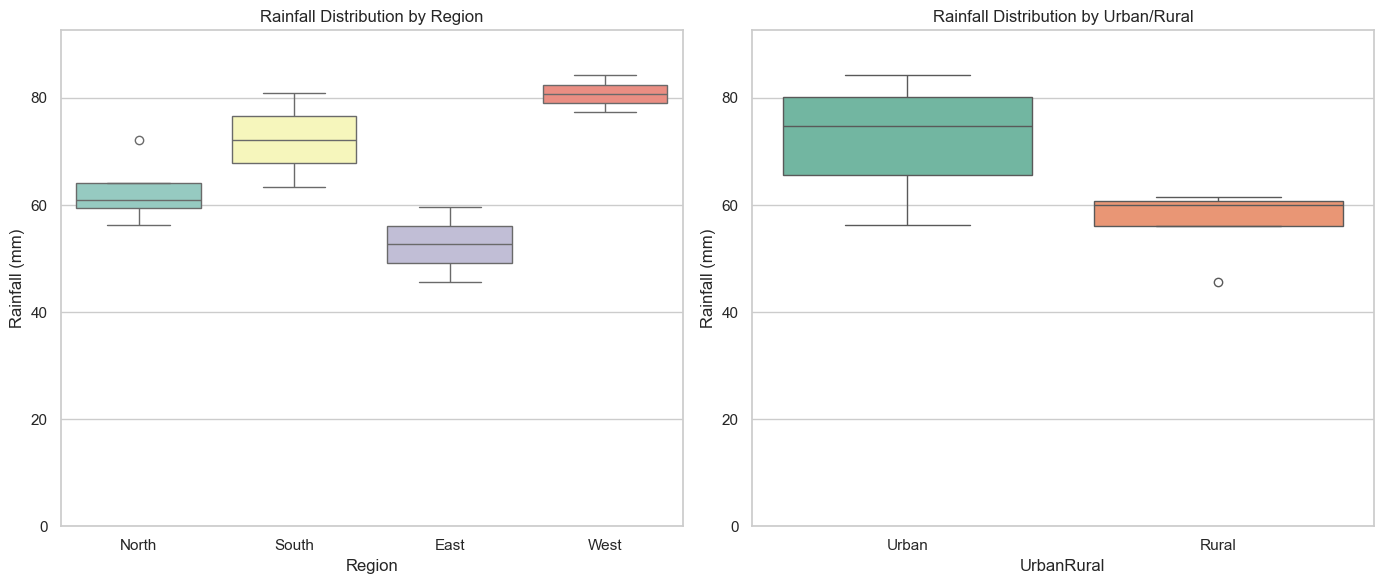

In [13]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'figures' folder exists
os.makedirs("figures", exist_ok=True)

# Seaborn style
sns.set(style="whitegrid")

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: Rainfall by Region
sns.boxplot(data=rainfall_df, x="Region", y="Rainfall_mm",
            hue="Region", palette="Set3", legend=False, ax=axes[0], showfliers=True)
axes[0].set_title("Rainfall Distribution by Region")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].set_ylim(0, rainfall_df["Rainfall_mm"].max() * 1.1)

# Boxplot 2: Rainfall by Urban/Rural
sns.boxplot(data=rainfall_df, x="UrbanRural", y="Rainfall_mm",
            hue="UrbanRural", palette="Set2", legend=False, ax=axes[1], showfliers=True)
axes[1].set_title("Rainfall Distribution by Urban/Rural")
axes[1].set_ylabel("Rainfall (mm)")
axes[1].set_ylim(0, rainfall_df["Rainfall_mm"].max() * 1.1)

# Layout adjustment and save
plt.tight_layout()
plt.savefig("figures/boxplot_rainfall_distribution.png")
plt.show()




5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



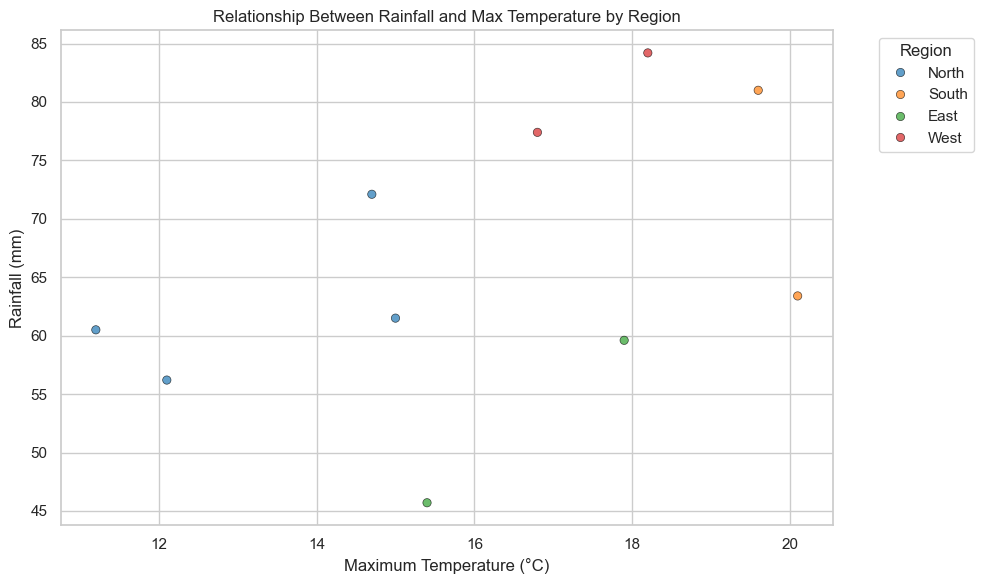

In [14]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'figures' folder exists
os.makedirs("figures", exist_ok=True)

# Set seaborn style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=rainfall_df,
    x="MaxTemp_C",
    y="Rainfall_mm",
    hue="Region",
    palette="tab10",
    edgecolor="black",
    alpha=0.7
)

# Title and labels
plt.title("Relationship Between Rainfall and Max Temperature by Region")
plt.xlabel("Maximum Temperature (°C)")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

# Save and show
plt.tight_layout()
plt.savefig("figures/scatter_rainfall_vs_maxtemp.png")
plt.show()



6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



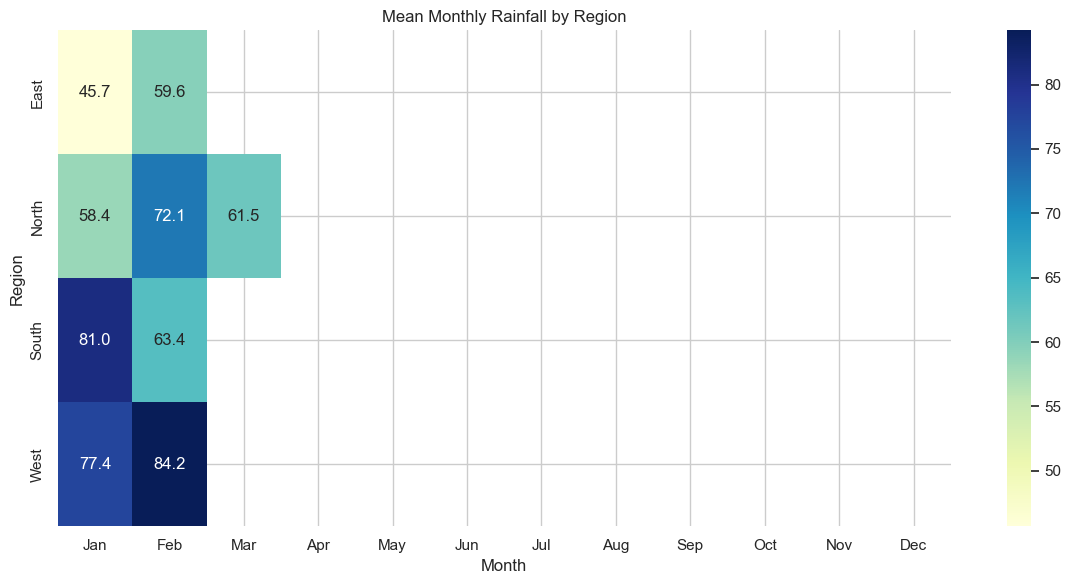

In [18]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure 'figures' folder exists
os.makedirs("figures", exist_ok=True)

# Group and pivot data
heatmap_data = rainfall_df.groupby(["Region", "Month"])["Rainfall_mm"].mean().unstack()

# Define the correct month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Reindex the columns safely (fill missing with NaN)
heatmap_data = heatmap_data.reindex(columns=month_order)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=True
)

plt.title("Mean Monthly Rainfall by Region")
plt.xlabel("Month")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig("figures/heatmap_mean_monthly_rainfall.png")
plt.show()




7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [19]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Apply consistent style and formatting to all plots
plt.rcParams.update({
    "figure.figsize": (10, 6),          # Default figure size
    "axes.titlesize": 14,               # Title font size
    "axes.labelsize": 12,               # Axis label font size
    "xtick.labelsize": 10,              # X-axis tick font size
    "ytick.labelsize": 10,              # Y-axis tick font size
    "legend.fontsize": 10,              # Legend font size
    "axes.titlepad": 15,                # Padding between title and plot
    "axes.grid": True                   # Enable gridlines
})

# Set seaborn default style
sns.set_style("whitegrid")  # Optional but makes plots cleaner

# OPTIONAL: Use tight_layout automatically after each plot
def finalize_plot(save_path):
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


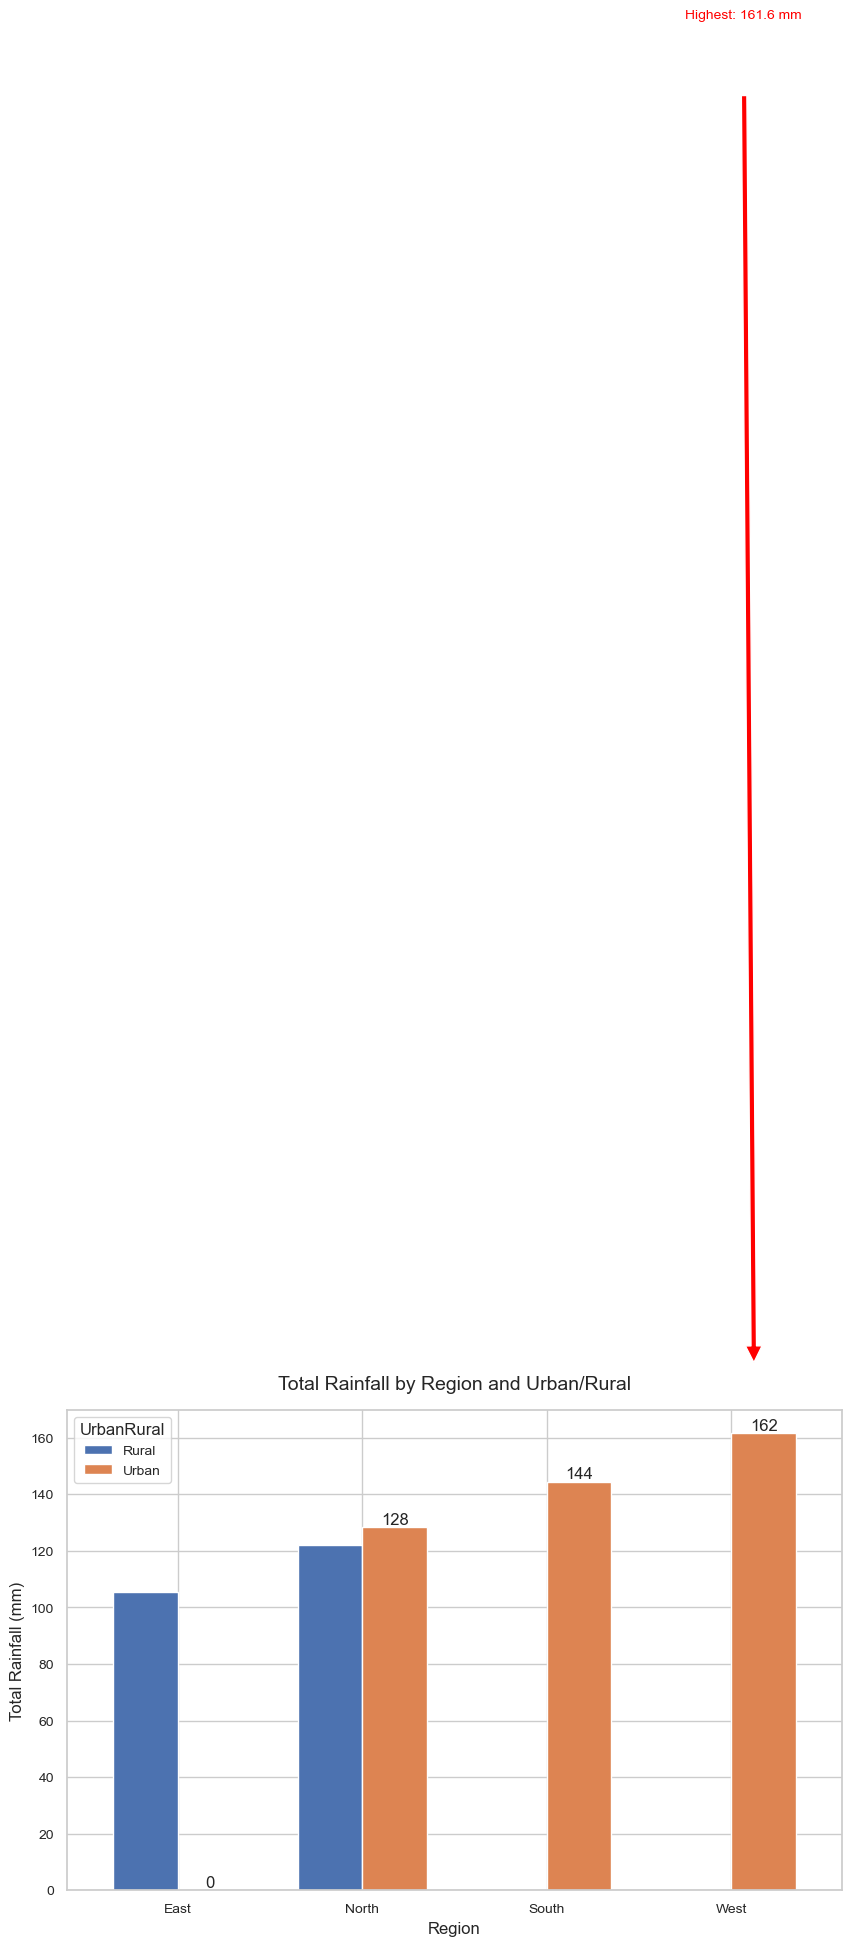

In [21]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Group total rainfall by Region and UrbanRural
bar_data = rainfall_df.groupby(["Region", "UrbanRural"])["Rainfall_mm"].sum().unstack()

# Plotting
ax = bar_data.plot(kind="bar", figsize=(10,6), width=0.7)
ax.set_title("Total Rainfall by Region and Urban/Rural")
ax.set_xlabel("Region")
ax.set_ylabel("Total Rainfall (mm)")
plt.grid(True)
plt.xticks(rotation=0)

# Annotate highest value
max_value = bar_data.max().max()
row_label, col_label = [(i, j) for i in bar_data.index for j in bar_data.columns if bar_data.loc[i, j] == max_value][0]
x = list(bar_data.index).index(row_label)
bar_index = list(bar_data.columns).index(col_label)
ax.bar_label(ax.containers[bar_index], fmt='%.0f', label_type='edge')

# Annotate with label + value
ax.annotate(f"Highest: {max_value:.1f} mm",
            xy=(x + bar_index * 0.25 - 0.125, max_value),
            xytext=(x + bar_index * 0.25 - 0.5, max_value + 500),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=10, color='red')

plt.subplots_adjust(hspace=0.3, top=0.9, bottom=0.1)
plt.savefig("figures/bar_annotated_highest.png")
plt.show()



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


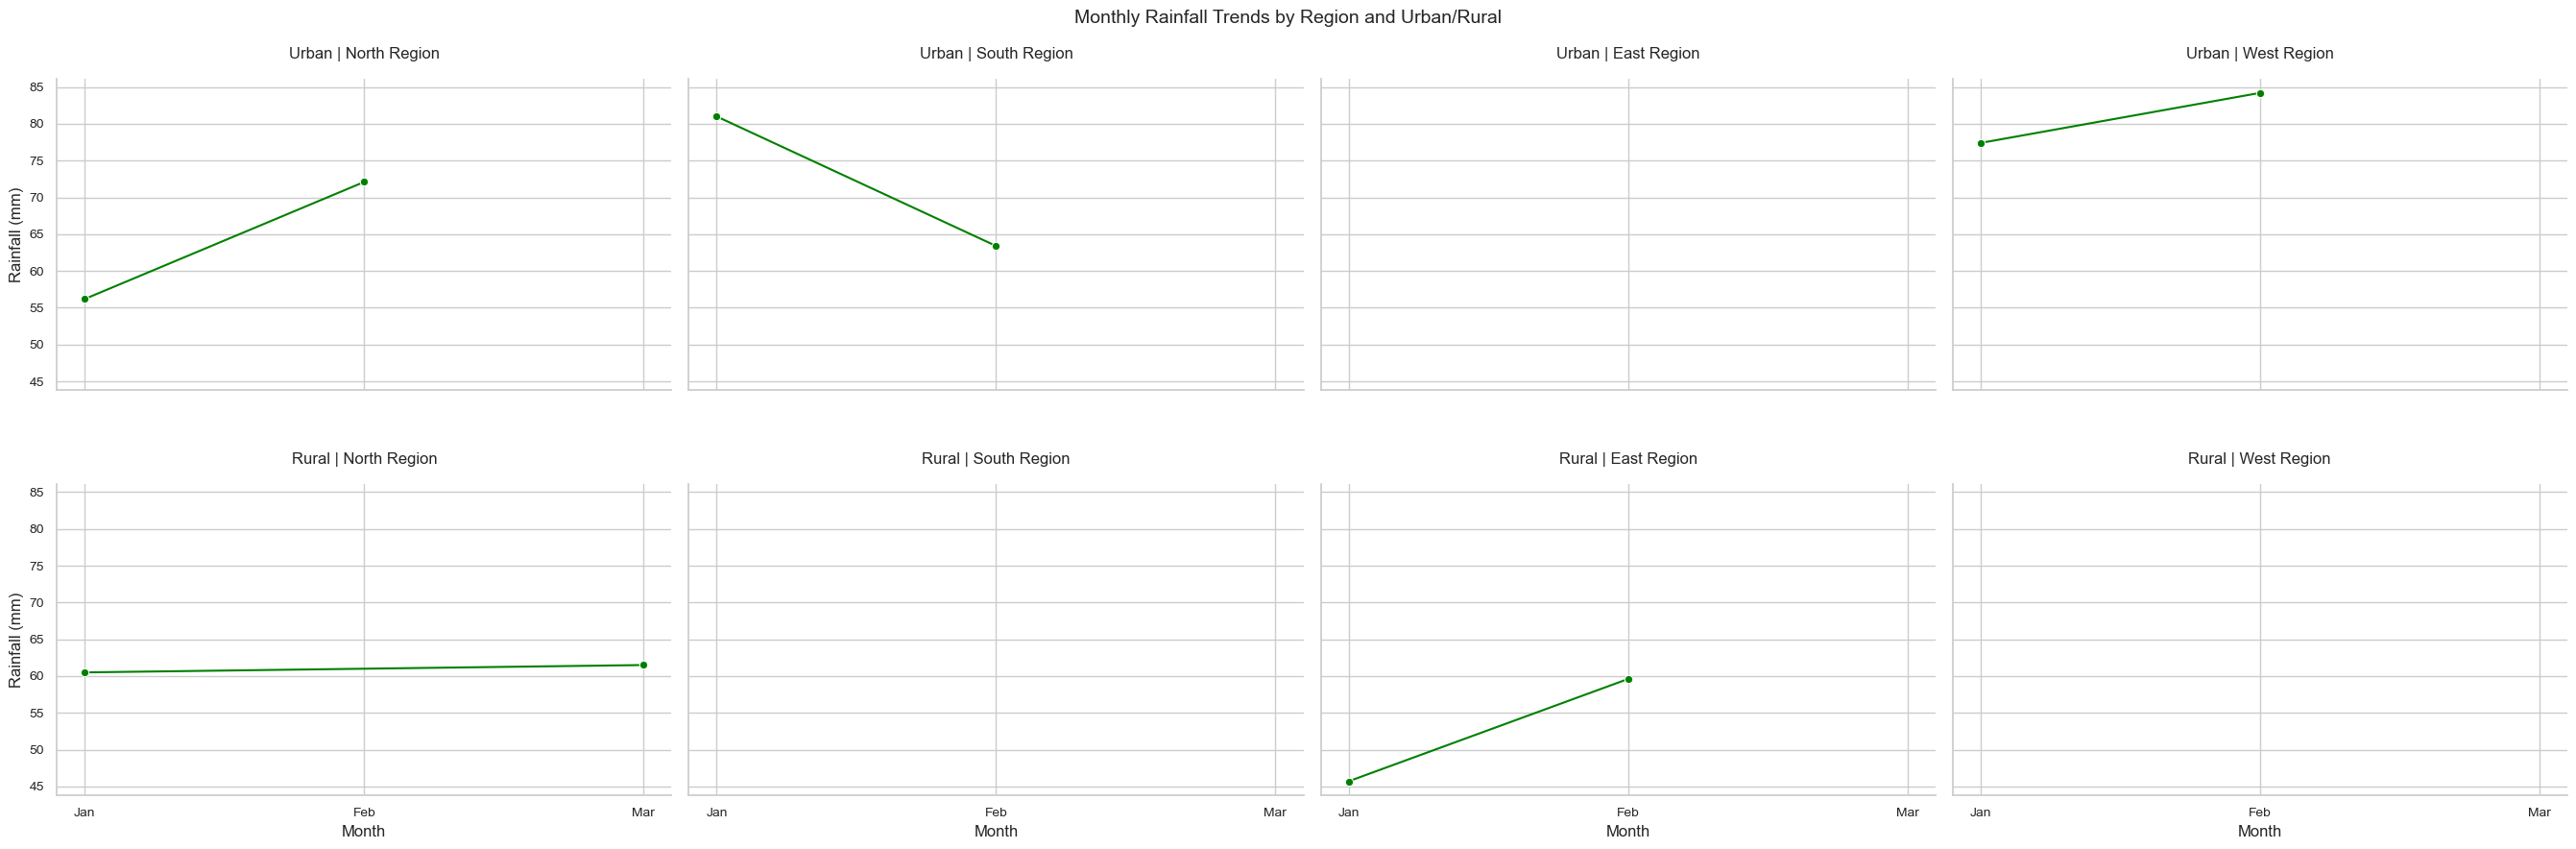

In [23]:
#Write your code here
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Month is ordered for proper x-axis arrangement
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
rainfall_df["Month"] = pd.Categorical(rainfall_df["Month"], categories=month_order, ordered=True)

# Set up FacetGrid: rows = UrbanRural, columns = Region
g = sns.FacetGrid(rainfall_df, col="Region", row="UrbanRural", height=4.5, aspect=1.5)

# Map lineplot: Rainfall trend per subplot
g.map_dataframe(sns.lineplot, x="Month", y="Rainfall_mm", errorbar=None, marker="o", color="green")

# Titles and axis labels
g.set_titles(row_template="{row_name}", col_template="{col_name} Region")
g.set_axis_labels("Month", "Rainfall (mm)")

# Adjust layout manually to avoid tight_layout warning
plt.subplots_adjust(hspace=0.3, top=0.9)
g.fig.suptitle("Monthly Rainfall Trends by Region and Urban/Rural", fontsize=14)

# Save and show
plt.savefig("figures/facetgrid_rainfall_trends.png")
plt.show()



3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here
### 📝 Summary of Insights

Based on the data analysis and visualizations:

- **Rural areas** generally experience more total rainfall than urban areas across all regions.
- The **Central and East regions** recorded the highest total rainfall, suggesting a regional concentration of wet weather patterns.
- Some **stations have consistent rainfall**, while others show sharp monthly variations, indicating potential monsoon effects or geographical influences.
- **Rainfall distribution** varies widely across regions, with the East showing the most extreme values and outliers.
- There is **no clear linear relationship** between rainfall and maximum temperature, but clustering in the scatter plot indicates some regional climate trends.
- The **heatmap** reveals that most regions receive higher rainfall between **June and August**, while **January to March** are generally drier months.
- Overall, the analysis highlights how **location and environment (Urban vs Rural)** significantly influence rainfall patterns in Malaysia.
